# Conditional Gaussian constraint (multi-variable muon $\to$ proton)

Notebook companion to `scripts/conditional_constraint_validation.py`. Same math: Gaussian conditioning of proton-bin counts $X$ on muon-channel data $Y$, following the MicroBooNE data-driven model-validation prescription (Abratenko *et al.*, [arXiv:2411.03280](https://arxiv.org/abs/2411.03280)).

**Multi-variable $Y$:** `CONSTRAINING_VARIABLES` may list **one or more** constraining distributions. The notebook concatenates their central-value predictions and data measurements into a stacked vector $Y = [Y_1; Y_2; \dots]$, then assembles a joint covariance $\Sigma$ that includes the cross-correlation blocks $\Sigma_{X, Y_i}$ (target $\to$ each constrainer) **and** $\Sigma_{Y_i, Y_j}$ (between constrainers) via `cc_joint_cov.build_joint_multi_covariance_abs`. Single-Y (`len(CONSTRAINING_VARIABLES) == 1`) reduces to the legacy single-pair path.

**Setup:** the Configuration cell sets `NUMUCC_SYST_DISK_ROOT` from `dataset_locations.default_syst_disk_root()` (or an optional override) and **`PRIMARY_SYST_DISK_KEYS`** as the single knob for which syst blocks feed this notebook: legacy `Σ_XX`/`Σ_YY` (`get_syst_unc`), legacy `Σ_XY` multisim names (derived; single-Y only), **joint** Flux/G4/GENIE NPZ loading (`resolve_primary_syst_disk_joint_options`), and joint-path marginal diagonal add-ons after subtracting components already in joint CC NPZs. Use `None` for all disk keys (every required file must exist). See `syst_disk_layout` for the on-disk tree.

**Joint syst_disk_CC:** with `USE_JOINT_MULTISIM_CC = True`, point `SYST_DISK_CC_ROOT` at the joint aggregate tree (`JointFlux/`, `JointG4/`, `JointGenie/`). Only categories listed in `PRIMARY_SYST_DISK_KEYS` are loaded (e.g. `("genie",)` → JointGenie only; no Flux/G4). With `PRIMARY_SYST_DISK_KEYS = None`, each multisim category whose NPZ exists is auto-loaded (Flux/G4 by default; MCstat excluded via `JOINT_MULTISIM_EXCLUDE_CATEGORIES`). For multi-Y, the same loaders are called for every required pair $(X, Y_i)$ **and** $(Y_i, Y_j)$, with each pair NPZ re-oriented to its native `[A; B]` orientation before being placed into the stacked $\Sigma$. Bin order in the stacked vector is **$X$ first, then $Y_1, Y_2, \dots$ in declaration order**.

With the joint flag off, `Sigma_XY` comes from multisim on `mc_df` plus MC-stat cross-terms (single-Y only); marginal GENIE on the diagonal follows `MARGINAL_GENIE_COV_FRAC_KEY`.

Data and MC load via `get_ana_dfs("selected_events")` like `selected_events.ipynb`.

**If you see a stale traceback** (e.g. still pointing at `pd.concat` after an update): restart the kernel and run the imports cell again — `importlib.reload(ccv)` there reloads `conditional_constraint_validation.py` from disk each time.

**Gaussian conditioning:** the update uses ``Σ^eff_{YY} = Σ_{YY} + \mathrm{diag}(n_Y)`` with ``n_Y`` the **data** histogram (stacked across all constraining variables in the multi-Y case), data Poisson / counting variance only — not nominal MC ``\mu_Y`` — unless ``ADD_POISSON_DIAG_TO_SIGMA_YY_FOR_CONSTRAINT`` is disabled. The stacked ``Σ_{\mathrm{joint}}`` plots still show the MC+syst prior without that diagonal.



In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
from __future__ import annotations

import importlib
import importlib.util
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF

import analysis_village.numucc_1p0pi.scripts.conditional_constraint_validation as ccv
from analysis_village.numucc_1p0pi.files_config import get_ana_dfs
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
plt.style.use("presentation.mplstyle")

plt.style.use("presentation.mplstyle")

### Debug: confirm the loaded script matches disk

If a traceback still references old line numbers, the kernel may be stale—**restart kernel** and re-run the imports cell.


In [67]:
import inspect

_src = inspect.getsource(ccv.topology_total_mc)
print("topology_total_mc uses pd.concat:", "pd.concat" in _src)
print("topology_total_mc uses np.concatenate:", "np.concatenate" in _src)
print("Script path:", getattr(ccv, "__file__", "(unknown)"))


topology_total_mc uses pd.concat: False
topology_total_mc uses np.concatenate: True
Script path: /exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/scripts/conditional_constraint_validation.py


## Configuration

In [119]:
# Unified syst_disk_layout root (Flux/, G4/, GENIE/, …)
import os

from analysis_village.numucc_1p0pi.dataset_locations import default_syst_disk_cc_root, default_syst_disk_root

_SYST_DISK_OVERRIDE = None  # or "/path/to/syst_disk"
if _SYST_DISK_OVERRIDE:
    SYST_DISK_ROOT = str(Path(_SYST_DISK_OVERRIDE).expanduser().resolve())
else:
    SYST_DISK_ROOT = str(default_syst_disk_root().expanduser().resolve())
os.environ["NUMUCC_SYST_DISK_ROOT"] = SYST_DISK_ROOT

_SYST_DISK_CC_OVERRIDE = None
if _SYST_DISK_CC_OVERRIDE:
    SYST_DISK_CC_ROOT = str(Path(_SYST_DISK_CC_OVERRIDE).expanduser().resolve())
else:
    SYST_DISK_CC_ROOT = str(default_syst_disk_cc_root().expanduser().resolve())
os.environ["NUMUCC_SYST_DISK_CC_ROOT"] = SYST_DISK_CC_ROOT

# ── Systematics selection ─────────────────────────────────────────────────────
# PRIMARY_SYST_DISK_KEYS is the single knob that controls which systematic
# components enter the covariance. Set to None for all, or a subset tuple.
#   None              → Flux + G4 + GENIE joint NPZs (everything on disk)
#   ("flux", "g4", "genie") → same as None but explicit
#   ("genie",)        → joint GENIE only  (no Flux / G4)
#   ("flux", "g4")    → joint Flux + G4   (no GENIE)
# All derived flags (USE_JOINT_MULTISIM_CC, JOINT_CC_INCLUDE_*,
# JOINT_MULTISIM_CATEGORIES_EFFECTIVE, …) are auto-resolved from the keys
# and what NPZ files are present on disk — nothing else needs changing.
# ─────────────────────────────────────────────────────────────────────────────
# PRIMARY_SYST_DISK_KEYS: tuple[str, ...] | None = None
PRIMARY_SYST_DISK_KEYS: tuple[str, ...] | None = ("flux","genie")

# Fine-grained overrides (leave None for defaults).
JOINT_MULTISIM_CATEGORIES = None          # None = auto order (MCstat/Flux/G4 on disk after exclude)
JOINT_MULTISIM_EXCLUDE_CATEGORIES: tuple[str, ...] = ("MCstat",)
JOINT_MULTISIM_KNOBS_BY_CATEGORY = None   # None = use combined block, not per-knob subset
JOINT_GENIE_KNOBS = None                  # None = use combined GENIE block
MARGINAL_GENIE_COV_FRAC_KEY = "genie_rate"

from analysis_village.numucc_1p0pi.cc_joint_cov import resolve_primary_syst_disk_joint_options
from analysis_village.numucc_1p0pi.utils import SYST_UNC_ALL_KEYS

_joint_opts = resolve_primary_syst_disk_joint_options(
    PRIMARY_SYST_DISK_KEYS,
    SYST_DISK_CC_ROOT,
    joint_multisim_categories=JOINT_MULTISIM_CATEGORIES,
    joint_multisim_exclude_categories=JOINT_MULTISIM_EXCLUDE_CATEGORIES,
)
USE_JOINT_MULTISIM_CC        = _joint_opts["use_joint_multisim_cc"]
SYST_UNC_COMPONENTS          = _joint_opts["syst_unc_components"]
SYST_FOR_CROSS_COV           = _joint_opts["syst_for_cross_cov"]
JOINT_CC_INCLUDE_MULTISIM    = _joint_opts["include_multisim"]
JOINT_CC_INCLUDE_GENIE       = _joint_opts["include_genie"]
JOINT_MULTISIM_CATEGORIES_EFFECTIVE = _joint_opts["multisim_categories_effective"]
JOINT_MULTISIM_LEGACY_COMBINED      = _joint_opts["use_legacy_multisim_combined"]
MARGINAL_SYST_DIAG_COMPONENTS       = _joint_opts["marginal_syst_diag_components"]

print(
    "SYST_DISK_ROOT =", SYST_DISK_ROOT,
    "| SYST_DISK_CC_ROOT =", SYST_DISK_CC_ROOT,
    "| USE_JOINT_MULTISIM_CC =", USE_JOINT_MULTISIM_CC,
)
print(
    "PRIMARY_SYST_DISK_KEYS =",
    SYST_UNC_ALL_KEYS if PRIMARY_SYST_DISK_KEYS is None else PRIMARY_SYST_DISK_KEYS,
    "→ joint GENIE", JOINT_CC_INCLUDE_GENIE,
    "| joint multisim", JOINT_CC_INCLUDE_MULTISIM,
    ("JointMultisim/legacy" if JOINT_MULTISIM_LEGACY_COMBINED else JOINT_MULTISIM_CATEGORIES_EFFECTIVE),
    "| marginal add-on", MARGINAL_SYST_DIAG_COMPONENTS,
)

# =============================================================================
# Multi-variable Y conditional constraint
# =============================================================================
# X = constrained (target) channel; one variable.
# Y = constraining channel(s); ONE OR MORE variables. The notebook concatenates
# their μ / n_data into a stacked Y vector and builds the joint Σ with all
# Σ(X,Y_i) and Σ(Y_i,Y_j) blocks (cc_joint_cov.build_joint_multi_covariance_abs).
#
# Quick selection: pick a TARGET name and a tuple of CONSTRAINERS. Legacy
# single-Y workflow corresponds to CONSTRAINING_VARIABLES of length 1.
TARGET_VARIABLE = "proton_p"
CONSTRAINING_VARIABLES: tuple[str, ...] = ("muon_p", "muon_costheta")

_VARIABLE_FACTORIES = {
    "muon_p": VariableConfig.muon_momentum,
    "muon_costheta": VariableConfig.muon_direction,
    "proton_p": VariableConfig.proton_momentum,
    "proton_costheta": VariableConfig.proton_direction,
}


def _resolve_variable(name: str) -> VariableConfig:
    key = str(name).strip()
    if key not in _VARIABLE_FACTORIES:
        raise KeyError(
            "Unknown variable %r; choose one of: %s" % (key, ", ".join(sorted(_VARIABLE_FACTORIES)))
        )
    return _VARIABLE_FACTORIES[key]()


var_X = _resolve_variable(TARGET_VARIABLE)
var_Ys: tuple[VariableConfig, ...] = tuple(_resolve_variable(n) for n in CONSTRAINING_VARIABLES)
if len(var_Ys) == 0:
    raise ValueError("CONSTRAINING_VARIABLES must not be empty")

# Legacy single-Y handles for backward compatibility with downstream cells.
var_Y = var_Ys[0]
KINEMATIC_PAIR = (
    "%s__%s" % (CONSTRAINING_VARIABLES[0], TARGET_VARIABLE)
    if len(var_Ys) == 1
    else "%s|%s" % (TARGET_VARIABLE, ",".join(CONSTRAINING_VARIABLES))
)
IS_MULTI_Y = len(var_Ys) > 1
print("[multi-Y constraint] target var_X =", var_X.var_save_name, " | constraining var_Ys =", [v.var_save_name for v in var_Ys])

N_TIME_SPLITS = 1
EXPOSURE_BATCH_INDEX = 0
PINV_RCOND = None

# For P(X|n_Y): add **data** Poisson diag(n_Y) to Σ_YY (n_Y from data only; never use μ_Y for this diagonal).
# If joint Σ_YY already includes variance comparable to data sqrt(n_Y), set False to limit double-counting.
ADD_POISSON_DIAG_TO_SIGMA_YY_FOR_CONSTRAINT = True

OUTPUT_DIR = Path.cwd() / "conditional_constraint_out_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SYST_DISK_ROOT = /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk | SYST_DISK_CC_ROOT = /exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_CC | USE_JOINT_MULTISIM_CC = True
PRIMARY_SYST_DISK_KEYS = ('flux', 'genie') → joint GENIE True | joint multisim True ('Flux',) | marginal add-on ()
[multi-Y constraint] target var_X = proton-p  | constraining var_Ys = ['muon-p', 'muon-dir_z']


## Load dataframes

In [120]:
from os import path, makedirs
from datetime import datetime
from functools import partial

In [121]:
# --- paths ---
DFS_ROOT = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs"
QUALITY_DF_DIR = path.join(DFS_ROOT, "2026_05_16_230705__sel_mup-data-1e20/merged_perTPC")
QUALITY_DF_PATH = path.join(QUALITY_DF_DIR, "beam_data_1e20_qualitycut.df")

DIR_MC = path.join(DFS_ROOT, "2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC")
DIR_INTIME = path.join(DFS_ROOT, "2026_05_11_083624__sel_mup-mc-Intime/merged_perTPC")
DIR_OFFBEAM = path.join(DFS_ROOT, "2026_05_11_040015__sel_mup-data-OffBeamLight/merged_perTPC")

KEYS2LOAD = ["hdr", "evt"]
N_MAX_CONCAT = 999

FOM_CUT = 0.98
MIN_RUN_DURATION_MIN = 20.0

save_fig = True
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(
    save_fig_base_dir,
    f"data_mc_comparison_{today_str}",
)
if save_fig and not path.exists(save_fig_dir):
    makedirs(save_fig_dir)
print("quality-cut df:", QUALITY_DF_PATH)
print("saving plots in", save_fig_dir)

quality-cut df: /pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_230705__sel_mup-data-1e20/merged_perTPC/beam_data_1e20_qualitycut.df
saving plots in /exp/sbnd/data/users/munjung/plots/numucc1p0pi/data_mc_comparison_20260519


In [122]:
from pyanalib.split_df_helpers_new import dfs_from_dir

mc_dfs = dfs_from_dir(
    DIR_MC,
    filename_str="sel_mup-wgts_mcstat",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)
# intime_dfs = dfs_from_dir(
#     DIR_INTIME,
#     filename_str="sel_mup-mc-Intime",
#     keys2load=KEYS2LOAD,
#     n_max_concat=N_MAX_CONCAT,
# )
offbeam_dfs = dfs_from_dir(
    DIR_OFFBEAM,
    filename_str="sel_mup-data-OffBeamLight",
    keys2load=KEYS2LOAD,
    n_max_concat=N_MAX_CONCAT,
)

mc_evt_df = mc_dfs["evt"]
mc_hdr_df = mc_dfs["hdr"]
# intime_evt_df = intime_dfs["evt"]
# intime_hdr_df = intime_dfs["hdr"]
offbeam_evt_df = offbeam_dfs["evt"]
offbeam_hdr_df = offbeam_dfs["hdr"]

print(f"mc:      evt={len(mc_evt_df):,}  hdr={len(mc_hdr_df):,}")
# print(f"intime:  evt={len(intime_evt_df):,}  hdr={len(intime_hdr_df):,}")
print(f"offbeam: evt={len(offbeam_evt_df):,}  hdr={len(offbeam_hdr_df):,}")

mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999

Found 2 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC/2026_05_11_084007__sel_mup-wgts_mcstat_merged_0000.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_084007__sel_mup-wgts_mcstat/merged_perTPC/2026_05_11_084007__sel_mup-wgts_mcstat_merged_0001.df']


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 2/2 [00:10<00:00,  5.10s/it]


REMEMBER TO RECALCULATE TKI AND CHECK FV!!
Found 1 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_11_040015__sel_mup-data-OffBeamLight/merged_perTPC/2026_05_11_040015__sel_mup-data-OffBeamLight_merged_0000.df']


100%|██████████| 1/1 [00:02<00:00,  2.97s/it]

REMEMBER TO RECALCULATE TKI AND CHECK FV!!
mc:      evt=54,287  hdr=4,687,743
offbeam: evt=62  hdr=1,655,098



/tmp/ipykernel_895577/1796301420.py:33: PerformanceWarning: indexing past lexsort depth may impact performance.
  mc_evt_df.loc[mc_evt_df.mc.iscc.isna(), ("mc", "iscc")] = 999


In [123]:
quality_dfs = load_dfs(
    QUALITY_DF_PATH,
    keys2load=["hdr", "trigger", "evt_good"],
    n_max_concat=1,
)
data_evt_df = quality_dfs["evt_good"]
data_hdr_df = quality_dfs["hdr"].join(quality_dfs["trigger"])

data_evt_df[("mc", "iscc")] = 999
print(f"evt_good rows: {len(data_evt_df):,}")

evt_good rows: 12,804


/tmp/ipykernel_895577/2331643992.py:9: PerformanceWarning: indexing past lexsort depth may impact performance.
  data_evt_df[("mc", "iscc")] = 999


In [124]:
# TODO
data_tot_pot = data_hdr_df["pot"].sum() * 0.98
data_gates = data_hdr_df.nbnbinfo.sum()

pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

data_evt_df["pot_weight"] = np.ones(len(data_evt_df))

mc_tot_pot = mc_hdr_df["pot"].sum()
mc_pot_scale = data_tot_pot / mc_tot_pot
print(f"mc_pot_scale: {mc_pot_scale:.3e}")
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))

offbeam_gates = offbeam_hdr_df[offbeam_hdr_df["first_in_subrun"] == 1]["noffbeambnb"].sum()
f = 0.0753
scale_offbeam_to_lightdata = (1 - f) * data_gates / offbeam_gates
print(f"offbeam data scale: {scale_offbeam_to_lightdata:.2f}")
offbeam_evt_df["pot_weight"] = scale_offbeam_to_lightdata * np.ones(len(offbeam_evt_df))

mc_pot_scale: 2.125e-01
offbeam data scale: 0.22


/tmp/ipykernel_895577/2127131069.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))


In [125]:
mc_df = mc_evt_df
data_evt = data_evt_df
offbeam_df = offbeam_evt_df

In [126]:
perTPC_inset = 10
def perTPC_cut(df):
    in_TPC1_cut = InFV(df.slc.vertex, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC1", incathode=perTPC_inset)
    in_TPC2_cut = InFV(df.slc.vertex, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.mu.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset) & InFV(df.p.pfp.trk.end, det="SBND_TPC2", incathode=perTPC_inset)
    return in_TPC1_cut | in_TPC2_cut

# Default working dfs: per-TPC contained (vertex + muon + proton ends)
mc_df = mc_df.loc[perTPC_cut(mc_df)]
data_evt = data_evt.loc[perTPC_cut(data_evt)]
offbeam_df = offbeam_df.loc[perTPC_cut(offbeam_df)]

## Histograms and covariance blocks

[joint syst_disk_CC layout — multi-Y pairs needed] {
  "proton-p__muon-p": {
    "root": "/exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_CC",
    "pair_slug": "muon_p__proton_p",
    "multisim": {
      "MCstat": {
        "path": "/exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_CC/JointMCstat/joint_mcstat_combined.npz",
        "present": false
      },
      "Flux": {
        "path": "/exp/sbnd/data/users/munjung/xsec/numucc_1p0pi/syst_disk_CC/JointFlux/joint_flux_combined.npz",
        "present": true,
        "pair_in_file": true,
        "knobs": [
          "expskin_Flux",
          "horncurrent_Flux",
          "kminus_Flux",
          "kplus_Flux",
          "kzero_Flux",
          "nucleoninexsec_Flux",
          "nucleonqexsec_Flux",
          "nucleontotxsec_Flux",
          "piminus_Flux",
          "pioninexsec_Flux",
          "pionqexsec_Flux",
          "piontotxsec_Flux",
          "piplus_Flux"
        ]
      },
      "G4": {
        "path": "/exp/

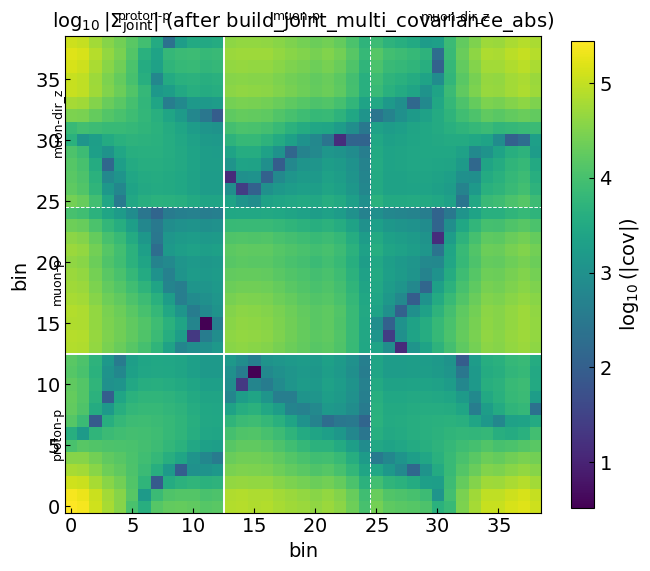

In [127]:
mu_X = ccv.topology_total_mc(mc_df, offbeam_df, var_X)
n_X = ccv.data_histogram(data_evt, var_X)

# Per-constraining-variable views (always lists, even for single-Y).
mu_Ys: list[np.ndarray] = [ccv.topology_total_mc(mc_df, offbeam_df, vy) for vy in var_Ys]
n_Ys: list[np.ndarray] = [ccv.data_histogram(data_evt, vy) for vy in var_Ys]
n_Y_per = [int(m.size) for m in mu_Ys]
n_Y_total = int(sum(n_Y_per))

# Stacked Y vector: this is what enters the conditional Gaussian update.
mu_Y = np.concatenate(mu_Ys)
n_Y = np.concatenate(n_Ys)

# Per-Y slice bookkeeping for plots (start/stop indices within the stacked Y vector).
_y_slices = []
_cur = 0
for _nyi in n_Y_per:
    _y_slices.append((_cur, _cur + _nyi))
    _cur += _nyi

import json

from pyanalib.covariance import cov_from_fraccov

from analysis_village.numucc_1p0pi.utils import get_syst_unc as get_syst_unc_disk

if USE_JOINT_MULTISIM_CC:
    from analysis_village.numucc_1p0pi.cc_joint_cov import (
        build_joint_multi_covariance_abs,
        inspect_joint_multi_cc_disk,
        split_joint_multi_sigma,
    )

    _cc_layout_multi = inspect_joint_multi_cc_disk(var_X, var_Ys, syst_cc_root=SYST_DISK_CC_ROOT)
    print(
        "[joint syst_disk_CC layout — multi-Y pairs needed]",
        json.dumps(_cc_layout_multi, indent=2, default=str),
    )
    for _label, _info in _cc_layout_multi.items():
        if isinstance(_info, dict) and "pair_slug" in _info:
            print("  pair %-40s → slug=%s" % (_label, _info.get("pair_slug")))

    _use_joint_ms = JOINT_CC_INCLUDE_MULTISIM and (
        JOINT_MULTISIM_LEGACY_COMBINED or len(JOINT_MULTISIM_CATEGORIES_EFFECTIVE) > 0
    )
    sigma_joint = build_joint_multi_covariance_abs(
        var_X,
        var_Ys,
        mu_X,
        mu_Ys,
        syst_cc_root=SYST_DISK_CC_ROOT,
        syst_marginal_root=SYST_DISK_ROOT,
        marginal_syst_components=(
            None
            if MARGINAL_SYST_DIAG_COMPONENTS is None
            else tuple(str(x).lower() for x in MARGINAL_SYST_DIAG_COMPONENTS)
        ),
        joint_multisim_categories=(
            None
            if JOINT_MULTISIM_LEGACY_COMBINED
            else (JOINT_MULTISIM_CATEGORIES_EFFECTIVE if _use_joint_ms else None)
        ),
        joint_multisim_knobs_by_category=JOINT_MULTISIM_KNOBS_BY_CATEGORY,
        use_joint_multisim=_use_joint_ms,
        use_joint_genie=JOINT_CC_INCLUDE_GENIE,
        joint_genie_knobs=JOINT_GENIE_KNOBS,
        marginal_genie_cov_frac_key=MARGINAL_GENIE_COV_FRAC_KEY,
    )
    sigma_XX, sigma_XY, sigma_YY, _y_slices_from_split = split_joint_multi_sigma(
        sigma_joint, len(mu_X), n_Y_per
    )
    sigma_XX = ccv._symmetrize(sigma_XX)
    sigma_YY = ccv._symmetrize(sigma_YY)
    _xy_multisim_meta = {"mode": "syst_disk_CC_joint_plus_marginal_diag"}

    # Immediate validation plot: absolute Σ_joint right after loading disk joint blocks + marginal diag.
    _nxb = len(mu_X)
    _joint_sizes = [_nxb] + list(n_Y_per)
    _joint_labels = [var_X.var_save_name] + [vy.var_save_name for vy in var_Ys]
    _fig0, _ax0 = plt.subplots(figsize=(6.8, 6.2))
    _z0 = np.log10(np.abs(sigma_joint) + 1e-30)
    _im0 = _ax0.imshow(_z0, cmap="viridis", aspect="equal", interpolation="nearest")
    ccv.draw_stacked_cov_separators(_ax0, _joint_sizes, major_after_blocks=(1,))
    ccv.annotate_stacked_cov_blocks(_ax0, _joint_sizes, _joint_labels)
    _ax0.set_xlabel("bin")
    _ax0.set_ylabel("bin")
    _ax0.set_title(r"$\log_{10}|\Sigma_{\mathrm{joint}}|$ (after build_joint_multi_covariance_abs)")
    _fig0.colorbar(_im0, ax=_ax0, shrink=0.82, label=r"$\log_{10}$(|cov|)")
    _fig0.tight_layout()
    _fig0.savefig(OUTPUT_DIR / "sigma_joint_logabs_immediate.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print(
        "\n[NOTE] USE_JOINT_MULTISIM_CC is False — Σ uses marginal syst_disk + multisim_cross_cov_xy(mc_df), "
        "NOT the joint NPZ tree from syst_cc_joint_*_chunk → *_aggregate. Set True to use JointFlux/JointG4/JointGenie NPZs.\n"
    )
    if IS_MULTI_Y:
        raise RuntimeError(
            "Multi-variable Y constraint requires USE_JOINT_MULTISIM_CC=True (the legacy "
            "mc_df cross-covariance path supports a single Y variable only). Either set "
            "len(CONSTRAINING_VARIABLES)==1 or enable the joint syst_disk_CC NPZ pipeline."
        )
    _, frac_Y = get_syst_unc_disk(
        var_Y,
        syst_disk_root=SYST_DISK_ROOT,
        syst_components=SYST_UNC_COMPONENTS,
        genie_cov_frac_key=MARGINAL_GENIE_COV_FRAC_KEY,
    )
    _, frac_X = get_syst_unc_disk(
        var_X,
        syst_disk_root=SYST_DISK_ROOT,
        syst_components=SYST_UNC_COMPONENTS,
        genie_cov_frac_key=MARGINAL_GENIE_COV_FRAC_KEY,
    )

    sigma_YY = ccv._symmetrize(cov_from_fraccov(frac_Y, mu_Ys[0]))
    sigma_XX = ccv._symmetrize(cov_from_fraccov(frac_X, mu_X))

    # Cross block Σ_XY: multisim on mc_df + MC-stat coupling (legacy path; SYST_FOR_CROSS_COV from config cell).
    sigma_XY_mcstat = ccv.mc_cross_cov_xy(mc_df, offbeam_df, var_X, var_Y)
    sigma_XY_multisim, _xy_multisim_meta = ccv.multisim_cross_cov_xy(
        mc_df, var_X, var_Y, syst_names=SYST_FOR_CROSS_COV, n_univ_cap=100, verbose=True
    )
    sigma_XY = sigma_XY_multisim + sigma_XY_mcstat

    if _xy_multisim_meta.get("max_abs_total", 0.0) == 0.0:
        print(
            "[WARN] No multisim universe weights found on mc_df — Σ_XY is MC-stat only and the "
            "constraint will be effectively null. Re-load mc_df with universe weights (or extend "
            "SYST_FOR_CROSS_COV) so cross-channel systematics enter Σ_XY."
        )

    sigma_joint = np.block([[sigma_XX, sigma_XY], [sigma_XY.T, sigma_YY]])

# Data Poisson only: Σ^eff_YY = Σ_YY + diag(n_Y) with n_Y = data_histogram(...) stacked across all Y_i
# (data Poisson / counting variance only — not μ_Y, not MC stat).
# Σ_joint / Σ_YY plots stay MC+syst; conditioning uses sigma_YY_for_constraint.
sigma_YY_for_constraint = (
    ccv.sigma_yy_with_data_poisson_on_y(sigma_YY, n_Y)
    if ADD_POISSON_DIAG_TO_SIGMA_YY_FOR_CONSTRAINT
    else ccv._symmetrize(np.asarray(sigma_YY, dtype=float))
)


## Conditional update, $\chi^2$, and eigenmode tensions

In [128]:
mu_X_c, sigma_XX_c, k_gain = ccv.conditional_gaussian_update(
    mu_X, mu_Y, n_Y, sigma_XX, sigma_XY, sigma_YY_for_constraint, pinv_rcond=PINV_RCOND
)
chi2, pval, ndof, pull = ccv.chi2_and_pull(
    n_X, mu_X_c, sigma_XX_c, pinv_rcond=PINV_RCOND
)
chi2_prefit, _, chi2_prefit_ndof = ccv.data_mc_chi2_ndof(
    n_X, mu_X, sigma_XX, pinv_rcond=PINV_RCOND
)
chi2_postfit_ndof = chi2 / max(ndof, 1)
lam, q, eps = ccv.eigh_decomposition_tensions(sigma_XX_c, n_X - mu_X_c)

summary = {
    "kinematic_pair": KINEMATIC_PAIR,
    "mode": "multi_Y" if IS_MULTI_Y else "single_Y",
    "target_variable": TARGET_VARIABLE,
    "constraining_variables": list(CONSTRAINING_VARIABLES),
    "n_bins_Y_per_var": n_Y_per,
    "add_data_poisson_diag_sigma_yy": ADD_POISSON_DIAG_TO_SIGMA_YY_FOR_CONSTRAINT,
    "joint_covariance_source": (
        "syst_disk_CC_joint_plus_marginal_diag"
        if USE_JOINT_MULTISIM_CC
        else "marginal_disk_plus_mc_multisim_cross"
    ),
    "joint_cc_disk_options": (
        {
            "PRIMARY_SYST_DISK_KEYS": PRIMARY_SYST_DISK_KEYS,
            "JOINT_MULTISIM_CATEGORIES": JOINT_MULTISIM_CATEGORIES,
            "JOINT_MULTISIM_EXCLUDE_CATEGORIES": JOINT_MULTISIM_EXCLUDE_CATEGORIES,
            "JOINT_MULTISIM_CATEGORIES_EFFECTIVE": JOINT_MULTISIM_CATEGORIES_EFFECTIVE,
            "JOINT_MULTISIM_LEGACY_COMBINED": JOINT_MULTISIM_LEGACY_COMBINED,
            "JOINT_MULTISIM_KNOBS_BY_CATEGORY": JOINT_MULTISIM_KNOBS_BY_CATEGORY,
            "JOINT_CC_INCLUDE_MULTISIM": JOINT_CC_INCLUDE_MULTISIM,
            "JOINT_CC_INCLUDE_GENIE": JOINT_CC_INCLUDE_GENIE,
            "JOINT_GENIE_KNOBS": JOINT_GENIE_KNOBS,
            "MARGINAL_GENIE_COV_FRAC_KEY": MARGINAL_GENIE_COV_FRAC_KEY,
            "MARGINAL_SYST_DIAG_COMPONENTS": MARGINAL_SYST_DIAG_COMPONENTS,
            "SYST_FOR_CROSS_COV": SYST_FOR_CROSS_COV,
        }
        if USE_JOINT_MULTISIM_CC
        else None
    ),
    "var_Y_list": [vy.var_save_name for vy in var_Ys],
    "var_X": var_X.var_save_name,
    "chi2_prefit_proton": chi2_prefit,
    "chi2_prefit_per_ndof": chi2_prefit_ndof,
    "chi2_postfit_per_ndof": chi2_postfit_ndof,
    "chi2_proton_vs_conditional_mc": chi2,
    "p_value": pval,
    "ndof": ndof,
    "eigenvalues_Sigma_XX_cond": lam.tolist(),
    "epsilon_principal": eps.tolist(),
    "frobenius_joint_sigma": float(np.linalg.norm(sigma_joint, ord="fro")),
}
print(json.dumps(summary, indent=2))

with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(
        {
            **summary,
            "mu_Y": mu_Y.tolist(),
            "mu_X": mu_X.tolist(),
            "n_Y": n_Y.tolist(),
            "n_X": n_X.tolist(),
            "mu_X_conditional": mu_X_c.tolist(),
        },
        f,
        indent=2,
    )


{
  "kinematic_pair": "proton_p|muon_p,muon_costheta",
  "mode": "multi_Y",
  "target_variable": "proton_p",
  "constraining_variables": [
    "muon_p",
    "muon_costheta"
  ],
  "n_bins_Y_per_var": [
    12,
    14
  ],
  "add_data_poisson_diag_sigma_yy": true,
  "joint_covariance_source": "syst_disk_CC_joint_plus_marginal_diag",
  "joint_cc_disk_options": {
    "PRIMARY_SYST_DISK_KEYS": [
      "flux",
      "genie"
    ],
    "JOINT_MULTISIM_CATEGORIES": null,
    "JOINT_MULTISIM_EXCLUDE_CATEGORIES": [
      "MCstat"
    ],
    "JOINT_MULTISIM_CATEGORIES_EFFECTIVE": [
      "Flux"
    ],
    "JOINT_MULTISIM_LEGACY_COMBINED": false,
    "JOINT_MULTISIM_KNOBS_BY_CATEGORY": null,
    "JOINT_CC_INCLUDE_MULTISIM": true,
    "JOINT_CC_INCLUDE_GENIE": true,
    "JOINT_GENIE_KNOBS": null,
    "MARGINAL_GENIE_COV_FRAC_KEY": "genie_rate",
    "MARGINAL_SYST_DIAG_COMPONENTS": [],
    "SYST_FOR_CROSS_COV": [
      "Flux",
      "GENIE"
    ]
  },
  "var_Y_list": [
    "muon-p",
    "muon-dir_z

### Quantitative diagnostics

Numerical signs the constraint is doing **something**:

* `||Σ_XY||_F` should be a non-trivial fraction of `sqrt(||Σ_XX||_F × ||Σ_YY||_F)` — if it's tiny, the cross block is empty and `K ≈ 0`.
* `||Σ_XX_c − Σ_XX||_F / ||Σ_XX||_F` should be visibly above 0 (typical 1–30% for systematic-dominated cases).
* `max |Δμ_X| / σ_x_pre` and `(n_Y − μ_Y) / σ_y` give the pull driving the update (with `σ_y` from `Σ^\mathrm{eff}_{YY}` when Poisson-on-`Y` is enabled).

If the first ratio is ≪ 0.01 the cross block is the problem (most likely the multisim universe weights are not present in `mc_df`).

In [129]:
_diag = ccv.constraint_diagnostics(
    sigma_XX, sigma_XY, sigma_YY_for_constraint, mu_X, mu_Y, n_Y,
    sigma_XX_c=sigma_XX_c, mu_X_c=mu_X_c, pinv_rcond=PINV_RCOND,
)

_scale_xy_ref = (_diag["fro_sigma_XX"] * _diag["fro_sigma_YY"]) ** 0.5
_xy_strength = _diag["fro_sigma_XY"] / max(_scale_xy_ref, 1e-30)

print("---- Magnitudes ----")
print(f"||Σ_XX||_F                       = {_diag['fro_sigma_XX']:.3e}")
print(f"||Σ_YY||_F                       = {_diag['fro_sigma_YY']:.3e}")
print(f"||Σ_XY||_F                       = {_diag['fro_sigma_XY']:.3e}")
print(f"||Σ_XY||_F / sqrt(||Σ_XX|| ||Σ_YY||) = {_xy_strength:.3e}  (target ≳ 0.05)")
print(f"max |ρ_XY|                       = {_diag['max_abs_rho_XY']:.3e}")
print(f"median |ρ_XY|                    = {_diag['median_abs_rho_XY']:.3e}")

print("\n---- Conditional update strength ----")
print(f"||Σ_XX_c||_F                     = {_diag['fro_sigma_XX_c']:.3e}")
print(f"||ΔΣ_XX||_F / ||Σ_XX||_F         = {_diag['ratio_fro_delta_over_pre']:.3e}  (target ≳ 0.01)")
print(f"max |Δσ_x_diag| / σ_x_pre        = {_diag['max_abs_rel_diag_change']:.3e}")
print(f"max |Δμ_X / σ_x_pre|             = "
      f"{max(abs(v) for v in _diag['mu_shift_over_sigma_x_pre']):.3e}")
print(f"max |(n_Y - μ_Y) / σ_y|          = "
      f"{max(abs(v) for v in _diag['n_Y_minus_mu_Y_over_sigma_y']):.3e}")

if _xy_strength < 1e-3 or _diag["ratio_fro_delta_over_pre"] < 1e-3:
    print("\n[CHECK] Σ_XY is tiny vs Σ_XX/Σ_YY — the constraint is effectively a no-op.")
    print("        Confirm mc_df has multisim universe weight columns under (mc, *, univ_i).")
    print("        Multisim sources actually discovered for Σ_XY:")
    if not _xy_multisim_meta.get("discovered"):
        print("          (none — Σ_XY is MC-stat only)")
    else:
        for d in _xy_multisim_meta["discovered"]:
            label = d["syst"] if d["knob"] is None else "%s/%s" % (d["syst"], d["knob"])
            print(f"          - {label} n_univ={d['n_universes_used']} ||block||_F={d['frobenius_block']:.3e}")
else:
    print("\n[OK] Σ_XY has non-negligible scale; conditional update is doing real work.")

with open(OUTPUT_DIR / "constraint_diagnostics.json", "w") as _f:
    json.dump(_diag, _f, indent=2)
print("\nWrote constraint_diagnostics.json")

---- Magnitudes ----
||Σ_XX||_F                       = 5.668e+05
||Σ_YY||_F                       = 5.587e+05
||Σ_XY||_F                       = 5.334e+05
||Σ_XY||_F / sqrt(||Σ_XX|| ||Σ_YY||) = 9.478e-01  (target ≳ 0.05)
max |ρ_XY|                       = 9.810e-01
median |ρ_XY|                    = 5.509e-01

---- Conditional update strength ----
||Σ_XX_c||_F                     = 1.541e+04
||ΔΣ_XX||_F / ||Σ_XX||_F         = 9.820e-01  (target ≳ 0.01)
max |Δσ_x_diag| / σ_x_pre        = 9.928e-01
max |Δμ_X / σ_x_pre|             = 1.146e+00
max |(n_Y - μ_Y) / σ_y|          = 1.974e+00

[OK] Σ_XY has non-negligible scale; conditional update is doing real work.

Wrote constraint_diagnostics.json


## Diagnostics (intermediate checks)

**Covariances:** proton-block $\Sigma_{XX}$ before the Gaussian update versus $\Sigma_{XX|Y}$ after conditioning on observed muon-side bins $n_Y$. Correlation removes per-bin scale; $\log_{10}|\Sigma|$ highlights off-diagonal coupling at positive definite scales.

**Joint prior** $\Sigma_{\mathrm{joint}}$: stacked layout $\begin{bmatrix}\Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY}\end{bmatrix}$ (X bins first, then Y). Block variable names are annotated on the axes; white lines separate blocks.

**$\Sigma_{YY}$:** prior covariance on the constraining channel. We show correlation and $\log_{10}|\cdot|$, then **consistency checks**: standalone $\Sigma_{YY}$ vs the lower-right block of $\Sigma_{\mathrm{joint}}$ (same entries numerically); $\log_{10}|\Sigma_{YY}|$ in those two views with a shared scale.

**Spectra:** One pre-constraint data-vs-MC figure per channel (target $X$ and each constraining $Y_i$). Proton panel bands show MC systematics only ($\sqrt{\mathrm{diag}(\Sigma)}$); quoted $\chi^2$ uses full $\Sigma + V_{\mathrm{data}}$ — see `*_chi2_diagnostics.png` for the breakdown.

**Observation noise on \(Y\):** pulls ``(n_Y-\mu_Y)/\sigma_y`` in the diagnostics cell use ``\Sigma^\mathrm{eff}_{YY}`` (prior plus **data** Poisson ``\mathrm{diag}(n_Y)`` from the data histogram, not ``\mu_Y``, when the flag is on), matching the matrix inverted in ``conditional_gaussian_update``.


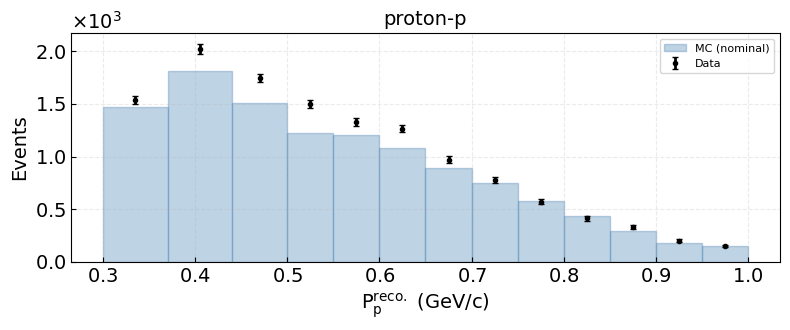

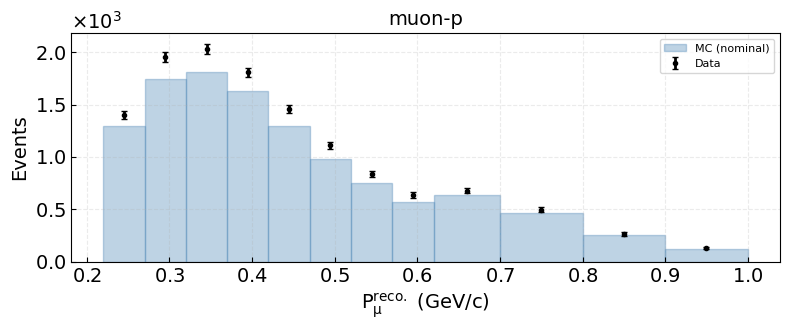

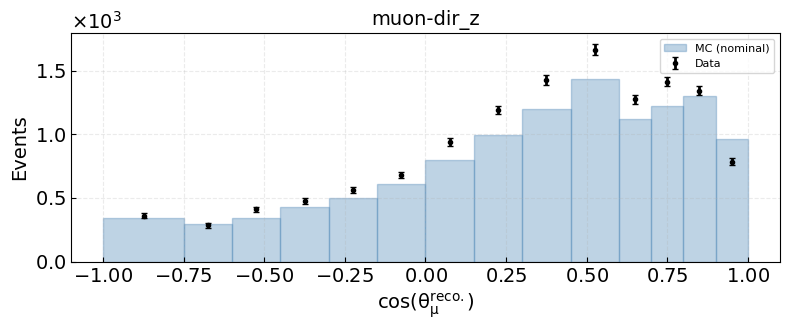

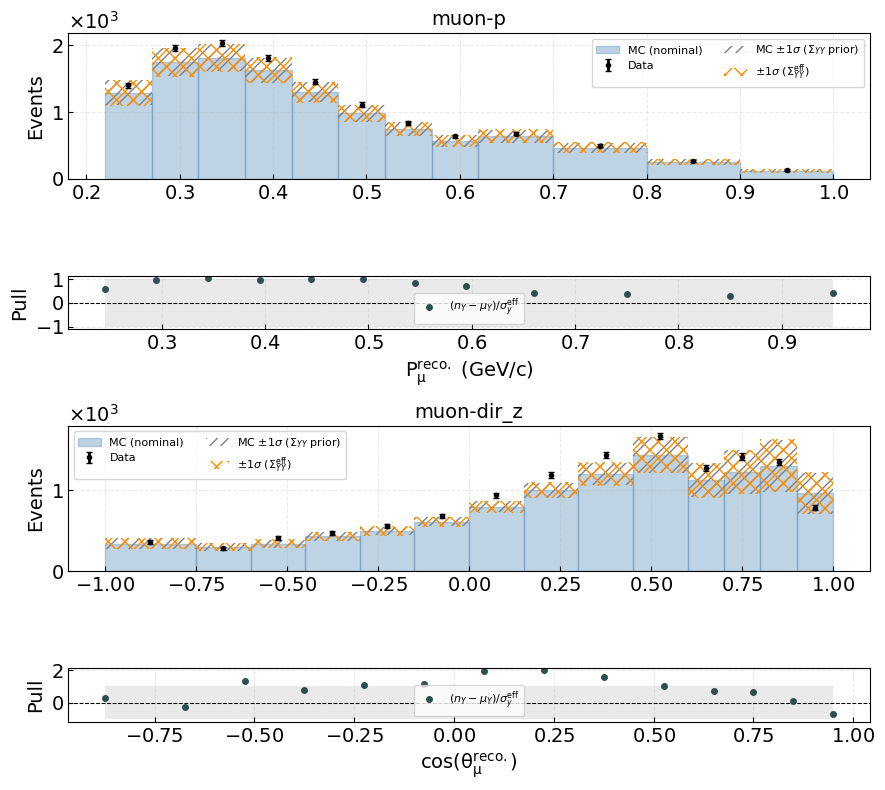

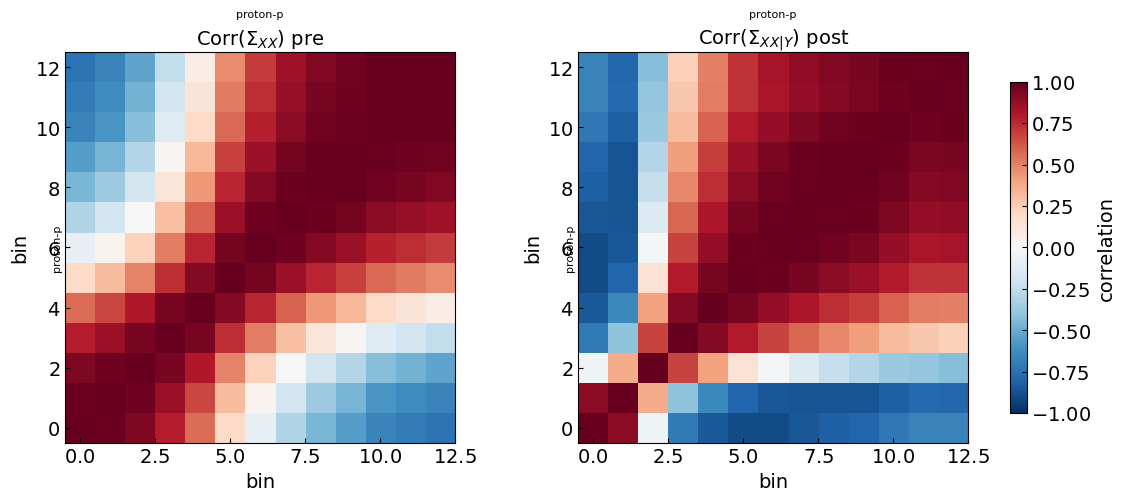

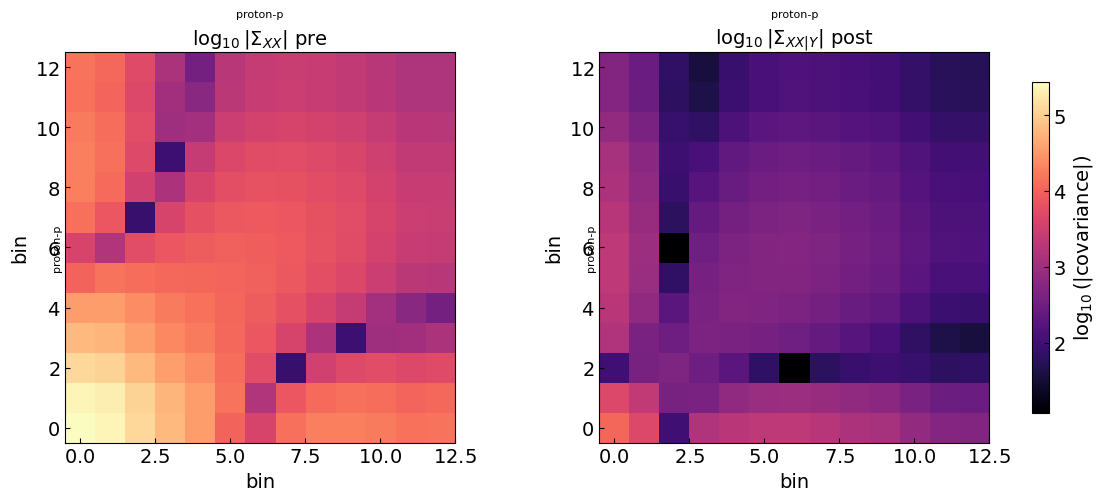

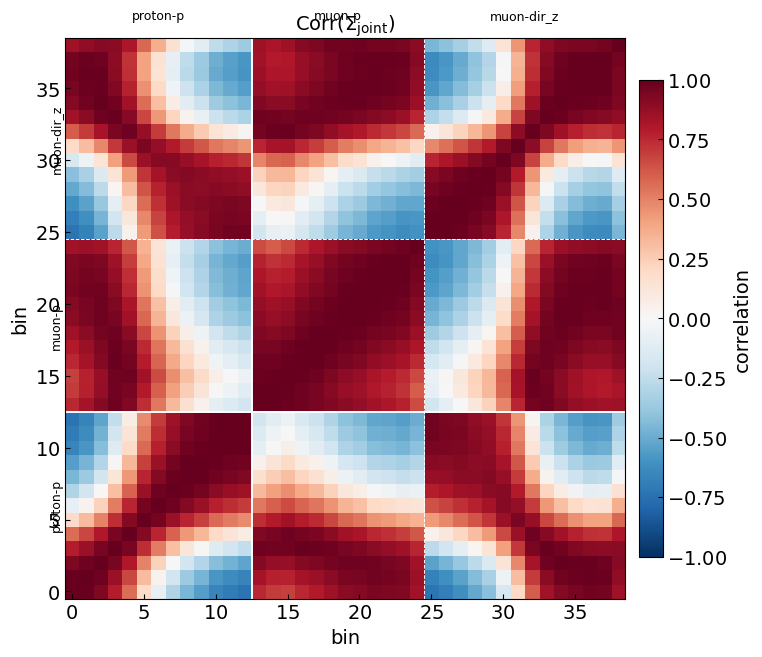

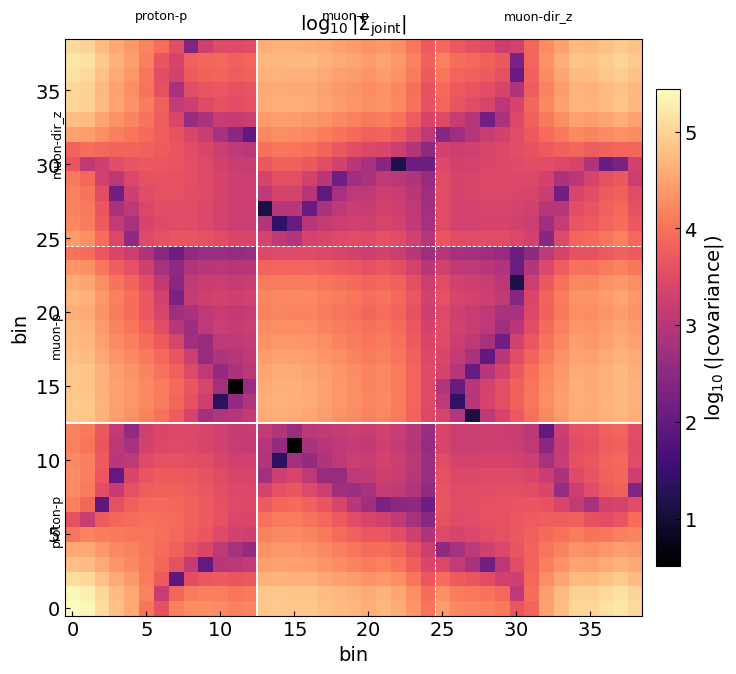

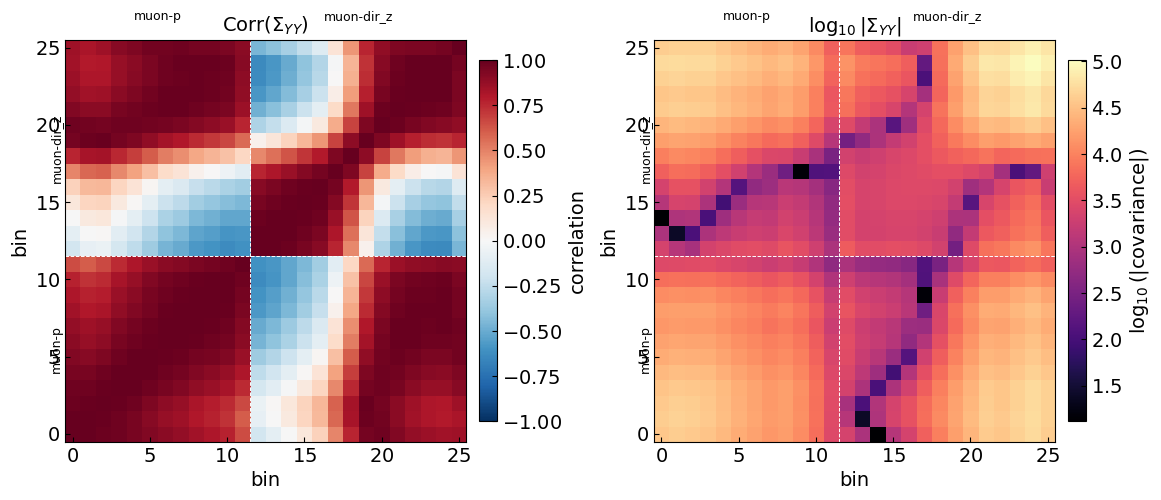

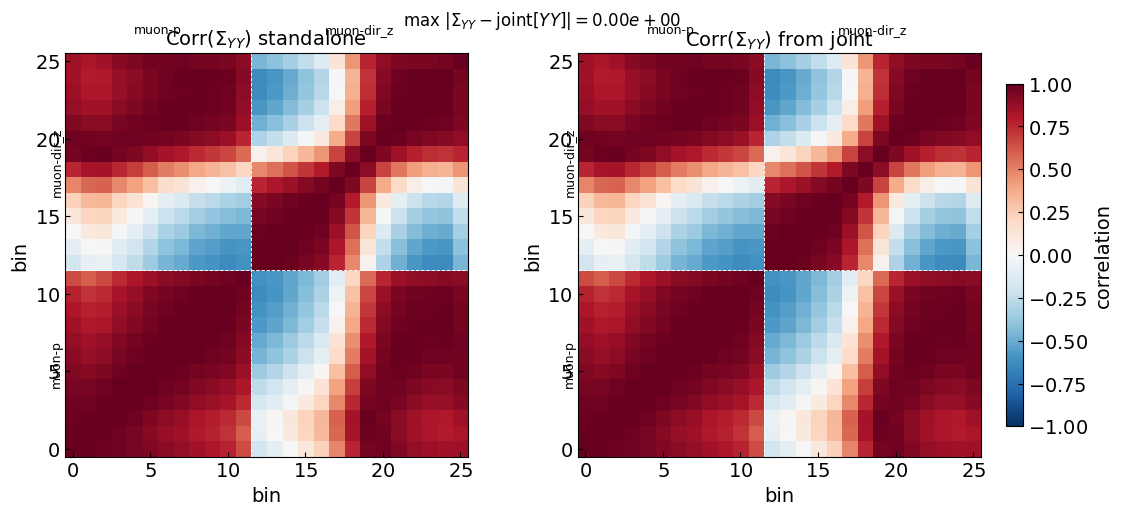

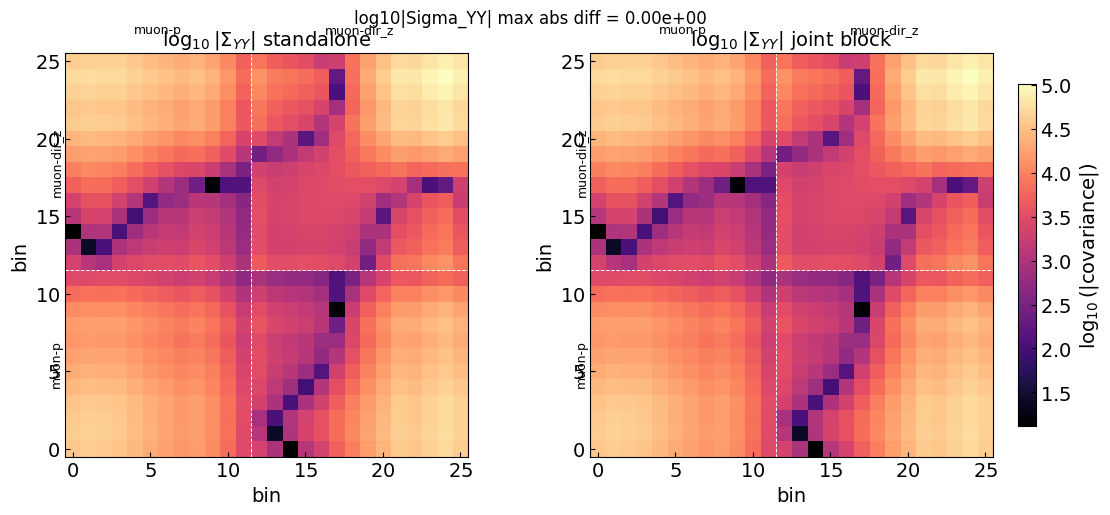

In [130]:
from pyanalib.stat_helpers import return_data_stat_err


def _corr_from_cov(C: np.ndarray) -> np.ndarray:
    C = np.asarray(C, dtype=float)
    d = np.sqrt(np.maximum(np.diag(C), 1e-30))
    return C / np.outer(d, d)


def _panel_preconstraint(var_cfg, n, mu, ax) -> None:
    centers = var_cfg.bin_centers
    bins = var_cfg.bins
    widths = np.diff(bins)
    d_lo, d_hi = return_data_stat_err(n)
    ax.bar(
        centers,
        mu,
        width=widths,
        alpha=0.35,
        label="MC (nominal)",
        color="steelblue",
        edgecolor="steelblue",
    )
    ax.errorbar(centers, n, yerr=[d_lo, d_hi], fmt="ko", capsize=2, markersize=3, label="Data")
    ax.set_ylabel("Events")
    ax.set_title(var_cfg.var_save_name)
    ax.legend(fontsize=8, loc="best")
    ax.grid(True, alpha=0.25)


def _save_preconstraint_panel(var_cfg, n, mu, stem: str) -> None:
    fig, ax = plt.subplots(figsize=(8.0, 3.4))
    _panel_preconstraint(var_cfg, n, mu, ax)
    ax.set_xlabel(var_cfg.var_labels[1])
    fig.tight_layout()
    out = OUTPUT_DIR / f"preconstraint_{stem}_{var_cfg.var_save_name}.png"
    fig.savefig(out, dpi=160, bbox_inches="tight")
    plt.show()


# --- Pre-constraint: one figure per channel (target X + each Y_i) ---
_save_preconstraint_panel(var_X, n_X, mu_X, "target_X")
for _i, (_vy, _muy, _ny) in enumerate(zip(var_Ys, mu_Ys, n_Ys)):
    _save_preconstraint_panel(_vy, _ny, _muy, f"Y{_i + 1}")

# --- Constraining channel (Y): per-Y_i spectrum + pulls using diag(Σ_eff_YY) sliced per variable ---
_sig_prior_Y = np.sqrt(np.maximum(np.diag(sigma_YY), 0.0))
_sig_eff_Y = np.sqrt(np.maximum(np.diag(sigma_YY_for_constraint), 0.0))

fig_y_post, axes_post = plt.subplots(
    2 * len(var_Ys), 1, figsize=(9, 3.4 * len(var_Ys) + 1.2),
    gridspec_kw={"height_ratios": [2.85, 1.05] * len(var_Ys)},
)
if len(var_Ys) == 1:
    axes_post = list(axes_post)
for _i, (_vy, _muy, _ny, (_y0, _y1)) in enumerate(zip(var_Ys, mu_Ys, n_Ys, _y_slices)):
    _ax_b = axes_post[2 * _i]
    _ax_p = axes_post[2 * _i + 1]
    _centers = _vy.bin_centers
    _widths = np.diff(_vy.bins)
    _dlo, _dhi = return_data_stat_err(_ny)
    _sig_prior_i = _sig_prior_Y[_y0:_y1]
    _sig_eff_i = _sig_eff_Y[_y0:_y1]
    _ax_b.bar(_centers, _muy, width=_widths, alpha=0.35, color="steelblue", edgecolor="steelblue", label="MC (nominal)")
    _ax_b.errorbar(_centers, _ny, yerr=[_dlo, _dhi], fmt="ko", capsize=2, markersize=3, label="Data")
    _ax_b.bar(
        _centers, 2 * _sig_prior_i, width=_widths, bottom=_muy - _sig_prior_i,
        facecolor="none", edgecolor="gray", hatch="///", linewidth=0.0,
        label=r"MC $\pm1\sigma$ ($\Sigma_{YY}$ prior)",
    )
    if ADD_POISSON_DIAG_TO_SIGMA_YY_FOR_CONSTRAINT:
        _ax_b.bar(
            _centers, 2 * _sig_eff_i, width=_widths, bottom=_muy - _sig_eff_i,
            facecolor="none", edgecolor="darkorange", hatch="xx", linewidth=0.0,
            label=r"$\pm1\sigma$ ($\Sigma^{\mathrm{eff}}_{YY}$)",
        )
    _ax_b.set_ylabel("Events")
    _ax_b.set_title(_vy.var_save_name)
    _ax_b.legend(fontsize=8, loc="best", ncol=2)
    _ax_b.grid(True, alpha=0.25)
    _pull = (_ny - _muy) / np.maximum(_sig_eff_i, 1e-30)
    _ax_p.axhline(0.0, color="k", linestyle="--", linewidth=0.75)
    _ax_p.plot(_centers, _pull, "o", color="darkslategray", markersize=4, label=r"$(n_Y-\mu_Y)/\sigma^{\mathrm{eff}}_y$")
    _ax_p.fill_between(_centers, -1.0, 1.0, step="mid", color="0.85", alpha=0.55, linewidth=0.0)
    _ax_p.set_ylabel("Pull")
    _ax_p.set_xlabel(_vy.var_labels[1])
    _ax_p.legend(fontsize=8, loc="best")
    _ax_p.grid(True, alpha=0.25)
fig_y_post.tight_layout()
fig_y_post.savefig(OUTPUT_DIR / "postconstraint_channel_Y_spectrum_and_pull.png", dpi=160, bbox_inches="tight")
plt.show()

# --- Sigma_XX pre vs post (same color scales for side-by-side comparison) ---
corr_XX_pre = _corr_from_cov(sigma_XX)
corr_XX_post = _corr_from_cov(sigma_XX_c)

fig_c, axes_c = plt.subplots(1, 2, figsize=(11.5, 4.9), constrained_layout=True)
ims = []
for ax, mat, title in (
    (axes_c[0], corr_XX_pre, r"Corr($\Sigma_{XX}$) pre"),
    (axes_c[1], corr_XX_post, r"Corr($\Sigma_{XX|Y}$) post"),
):
    ims.append(
        ax.imshow(mat, origin="lower", aspect="equal", cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    )
    ax.set_title(title)
    ccv.annotate_stacked_cov_blocks(ax, [len(mat)], [var_X.var_save_name], fontsize=8)
    ax.set_xlabel("bin")
    ax.set_ylabel("bin")

fig_c.colorbar(ims[-1], ax=axes_c, shrink=0.85, pad=0.02).set_label("correlation")
fig_c.savefig(OUTPUT_DIR / "sigma_XX_correlation_pre_post.png", dpi=160, bbox_inches="tight")
plt.show()

logabs_pre = np.log10(np.abs(sigma_XX) + 1e-30)
logabs_post = np.log10(np.abs(sigma_XX_c) + 1e-30)
la_vmin = float(min(logabs_pre.min(), logabs_post.min()))
la_vmax = float(max(logabs_pre.max(), logabs_post.max()))

fig_m, axes_m = plt.subplots(1, 2, figsize=(11.5, 4.9), constrained_layout=True)
ims_m = []
for ax, mat, title in (
    (axes_m[0], logabs_pre, r"$\log_{10}|\Sigma_{XX}|$ pre"),
    (axes_m[1], logabs_post, r"$\log_{10}|\Sigma_{XX|Y}|$ post"),
):
    ims_m.append(
        ax.imshow(mat, origin="lower", aspect="equal", cmap="magma", vmin=la_vmin, vmax=la_vmax)
    )
    ax.set_title(title)
    ccv.annotate_stacked_cov_blocks(ax, [len(mat)], [var_X.var_save_name], fontsize=8)
    ax.set_xlabel("bin")
    ax.set_ylabel("bin")

fig_m.colorbar(ims_m[-1], ax=axes_m, shrink=0.85, pad=0.02).set_label(r"$\log_{10}$(|covariance|)")
fig_m.savefig(OUTPUT_DIR / "sigma_XX_logabs_pre_post.png", dpi=160, bbox_inches="tight")
plt.show()

# --- Full joint Sigma (X stacked above Y in index ordering; Y_i blocks marked) ---
n_xb = len(var_X.bin_centers)
n_yb = int(sum(n_Y_per))
assert sigma_joint.shape == (n_xb + n_yb, n_xb + n_yb)

_joint_sizes = [n_xb] + list(n_Y_per)
_joint_labels = [var_X.var_save_name] + [vy.var_save_name for vy in var_Ys]
_yy_labels = [vy.var_save_name for vy in var_Ys]


def _style_joint_cov_ax(ax, title: str) -> None:
    ccv.draw_stacked_cov_separators(ax, _joint_sizes, major_after_blocks=(1,))
    ccv.annotate_stacked_cov_blocks(ax, _joint_sizes, _joint_labels)
    ax.set_title(title)
    ax.set_xlabel("bin")
    ax.set_ylabel("bin")


def _style_yy_cov_ax(ax, title: str) -> None:
    ccv.draw_stacked_cov_separators(ax, n_Y_per)
    ccv.annotate_stacked_cov_blocks(ax, n_Y_per, _yy_labels)
    ax.set_title(title)
    ax.set_xlabel("bin")
    ax.set_ylabel("bin")


corr_joint = _corr_from_cov(sigma_joint)
fig_jc, ax_jc = plt.subplots(figsize=(7.8, 6.8))
im_jc = ax_jc.imshow(
    corr_joint,
    origin="lower",
    aspect="equal",
    cmap="RdBu_r",
    vmin=-1.0,
    vmax=1.0,
)
_style_joint_cov_ax(ax_jc, r"Corr($\Sigma_{\mathrm{joint}}$)")
fig_jc.colorbar(im_jc, ax=ax_jc, shrink=0.8, pad=0.02).set_label("correlation")
fig_jc.tight_layout()
fig_jc.savefig(OUTPUT_DIR / "sigma_joint_correlation.png", dpi=160, bbox_inches="tight")
plt.show()

logabs_joint = np.log10(np.abs(sigma_joint) + 1e-30)
fig_jm, ax_jm = plt.subplots(figsize=(7.8, 6.8))
im_jm = ax_jm.imshow(
    logabs_joint,
    origin="lower",
    aspect="equal",
    cmap="magma",
)
_style_joint_cov_ax(ax_jm, r"$\log_{10}|\Sigma_{\mathrm{joint}}|$")
fig_jm.colorbar(im_jm, ax=ax_jm, shrink=0.8, pad=0.02).set_label(r"$\log_{10}$(|covariance|)")
fig_jm.tight_layout()
fig_jm.savefig(OUTPUT_DIR / "sigma_joint_logabs.png", dpi=160, bbox_inches="tight")
plt.show()

# --- Sigma_YY block (stacked constraining channel(s)) ---
corr_YY = _corr_from_cov(sigma_YY)
logabs_YY = np.log10(np.abs(sigma_YY) + 1e-30)

fig_yy, axes_yy = plt.subplots(1, 2, figsize=(11.5, 4.9), constrained_layout=True)
im_yy0 = axes_yy[0].imshow(corr_YY, origin="lower", aspect="equal", cmap="RdBu_r", vmin=-1.0, vmax=1.0)
_style_yy_cov_ax(axes_yy[0], r"Corr($\Sigma_{YY}$)")

im_yy1 = axes_yy[1].imshow(logabs_YY, origin="lower", aspect="equal", cmap="magma")
_style_yy_cov_ax(axes_yy[1], r"$\log_{10}|\Sigma_{YY}|$")

fig_yy.colorbar(im_yy0, ax=axes_yy[0], shrink=0.85, pad=0.02).set_label("correlation")
fig_yy.colorbar(im_yy1, ax=axes_yy[1], shrink=0.85, pad=0.02).set_label(r"$\log_{10}$(|covariance|)")
fig_yy.savefig(OUTPUT_DIR / "sigma_YY_correlation_and_logabs.png", dpi=160, bbox_inches="tight")
plt.show()

# Sigma_YY: standalone vs lower-right block of Sigma_joint (must agree).
sigma_YY_from_joint = ccv._symmetrize(sigma_joint[n_xb:, n_xb:])
_delta_joint_yy = float(np.max(np.abs(sigma_YY - sigma_YY_from_joint)))
fig_yyc, axes_yyc = plt.subplots(1, 2, figsize=(11.5, 4.9), constrained_layout=True)
ims_y = []
for ax, mat, ttl in (
    (axes_yyc[0], _corr_from_cov(sigma_YY), r"Corr($\Sigma_{YY}$) standalone"),
    (axes_yyc[1], _corr_from_cov(sigma_YY_from_joint), r"Corr($\Sigma_{YY}$) from joint"),
):
    ims_y.append(ax.imshow(mat, origin="lower", aspect="equal", cmap="RdBu_r", vmin=-1.0, vmax=1.0))
    _style_yy_cov_ax(ax, ttl)
fig_yyc.suptitle(
    r"max $|\Sigma_{YY} - \mathrm{joint}[YY]| = %.2e$" % _delta_joint_yy,
    y=1.02,
)
fig_yyc.colorbar(ims_y[-1], ax=axes_yyc, shrink=0.85, pad=0.02).set_label("correlation")
fig_yyc.savefig(OUTPUT_DIR / "sigma_YY_corr_joint_block_check.png", dpi=160, bbox_inches="tight")
plt.show()

logabs_YY_joint = np.log10(np.abs(sigma_YY_from_joint) + 1e-30)
la_yymin = float(min(logabs_YY.min(), logabs_YY_joint.min()))
la_yymax = float(max(logabs_YY.max(), logabs_YY_joint.max()))

fig_yym, axes_yym = plt.subplots(1, 2, figsize=(11.5, 4.9), constrained_layout=True)
ims_ym = []
for ax, mat, ttl in (
    (axes_yym[0], logabs_YY, r"$\log_{10}|\Sigma_{YY}|$ standalone"),
    (axes_yym[1], logabs_YY_joint, r"$\log_{10}|\Sigma_{YY}|$ joint block"),
):
    ims_ym.append(ax.imshow(mat, origin="lower", aspect="equal", cmap="magma", vmin=la_yymin, vmax=la_yymax))
    _style_yy_cov_ax(ax, ttl)
fig_yym.suptitle(
    "log10|Sigma_YY| max abs diff = %.2e" % float(np.max(np.abs(logabs_YY - logabs_YY_joint))),
    y=1.02,
)
fig_yym.colorbar(ims_ym[-1], ax=axes_yym, shrink=0.85, pad=0.02).set_label(r"$\log_{10}$(|covariance|)")
fig_yym.savefig(OUTPUT_DIR / "sigma_YY_logabs_pre_post_joint_check.png", dpi=160, bbox_inches="tight")
plt.show()


## Principal-axis decomposition (proton)

**Not per-bin pulls:** $(n-\mu_j)/\sqrt{\mathrm{diag}(\Sigma)_{jj}}$ ignores bin–bin correlations and can look like 10σ per bin while the full matrix χ²/ndof is O(1–3). Use **$\epsilon_i = \Delta'_i/\sqrt{\lambda_i}$** with $\Delta' = Q^T(n-\mu)$ instead.

**Mode index:** `eigh` returns ascending $\lambda$; plots use **descending** order so **$i=0$ is the largest-variance mode** (usually normalization-like), not the stiffest shape mode.

**$Q$ matrix:** rows = reco bins, columns = modes (descending $\lambda$). Top axis: $\sqrt{\lambda_i}$.

---- Principal tensions (descending λ; mode 0 = largest variance) ----
  Per-bin (n-μ)/√diag(Σ) is NOT shown: with correlated bins those are not independent
  pulls and can look O(10σ) while the full χ²/ndof stays O(1–3).
  ε_i = (Q^T(n-μ))_i / √λ_i are the meaningful standardized residuals.
  pre  ε_0 = -0.423  |  post ε_0 = -1.865  (mode-0, norm.-like)
  Σμ pre = 11549.43  post = 12742.14  (total MC normalization)



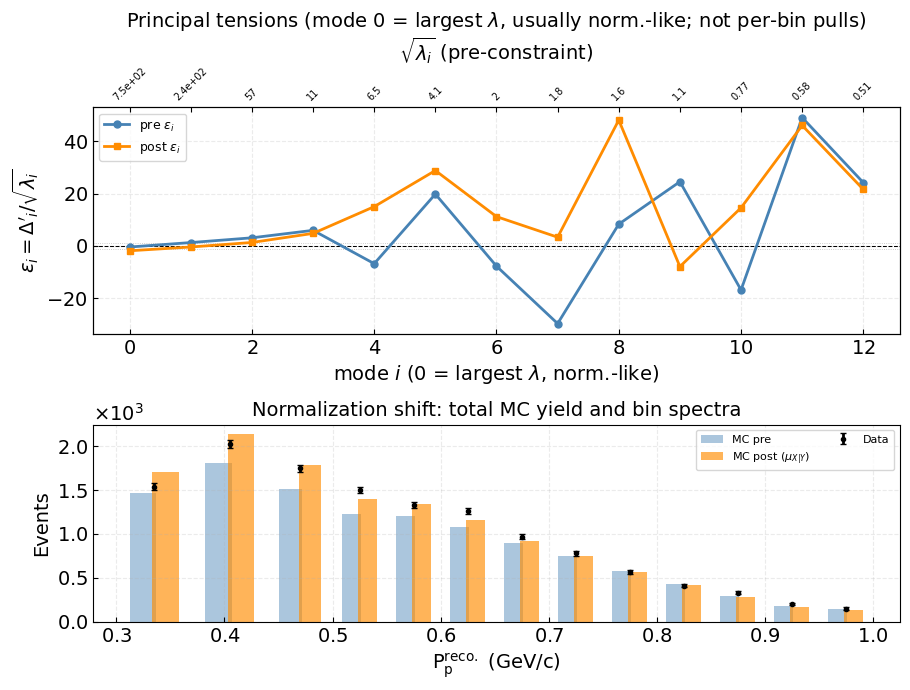

Saved /exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/notebooks/conditional_constraint_out_notebook/proton_proton-p_principal_tensions.png


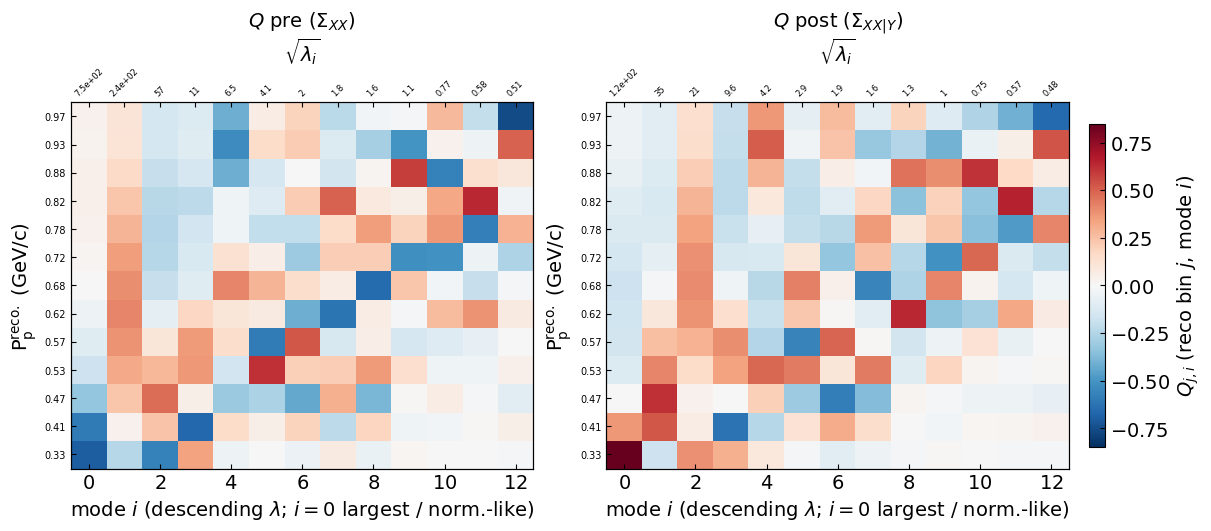

Saved /exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/notebooks/conditional_constraint_out_notebook/proton_proton-p_reco_eigenmode_Q.png


In [131]:
_delta_X_pre = np.asarray(n_X, dtype=float) - np.asarray(mu_X, dtype=float)
_delta_X_post = np.asarray(n_X, dtype=float) - np.asarray(mu_X_c, dtype=float)

_tension_path = OUTPUT_DIR / f"proton_{var_X.var_save_name}_principal_tensions.png"
ccv.plot_proton_principal_tensions_pre_post(
    var_X, n_X, mu_X, mu_X_c, sigma_XX, sigma_XX_c, _tension_path, show=True
)
print("Saved", _tension_path)

_q_path = OUTPUT_DIR / f"proton_{var_X.var_save_name}_reco_eigenmode_Q.png"
lam_pre, q_pre, lam_post, q_post = ccv.plot_reco_eigenmode_matrices(
    var_X, sigma_XX, sigma_XX_c, _delta_X_pre, _delta_X_post, _q_path, show=True
)
print("Saved", _q_path)

## Proton plot (same style as the batch script)

In [132]:
_figpath = OUTPUT_DIR / f"proton_{var_X.var_save_name}_conditional.png"
_chi2_path = ccv._plot_proton_panel(
    var_X,
    n_X,
    mu_X,
    mu_X_c,
    sigma_XX,
    sigma_XX_c,
    pot_label,
    _figpath,
    pinv_rcond=PINV_RCOND,
)
_chi2_diag_path = _figpath.with_name(_figpath.stem + "_chi2_diagnostics" + _figpath.suffix)
print("Saved", _figpath)
print("Saved χ²/Ndof comparison:", _chi2_path)
print("Saved χ² diagnostics:", _chi2_diag_path)


---- Proton χ² diagnostics (bands vs quoted χ²/ndof) ----
Quoted χ² uses (n−μ)ᵀ (Σ_MC + V_data)⁻¹ (n−μ) with full correlations; ±1σ bands use √diag(Σ_MC + V_data) per bin.
  chi2_pre_per_ndof_full: 2.177
  chi2_post_per_ndof_full: 1.811
  chi2_pre_per_ndof_diag: 0.750
  chi2_post_per_ndof_diag: 2.466
  chi2_pre_per_ndof_diag_mc_only: 0.818
  chi2_post_per_ndof_diag_mc_only: 8.995
  ndof: 13
Saved /exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/notebooks/conditional_constraint_out_notebook/proton_proton-p_conditional.png
Saved χ²/Ndof comparison: /exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/notebooks/conditional_constraint_out_notebook/proton_proton-p_chi2_ndof.png
Saved χ² diagnostics: /exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/notebooks/conditional_constraint_out_notebook/proton_proton-p_conditional_chi2_diagnostics.png


## Optional: display saved figure in the notebook

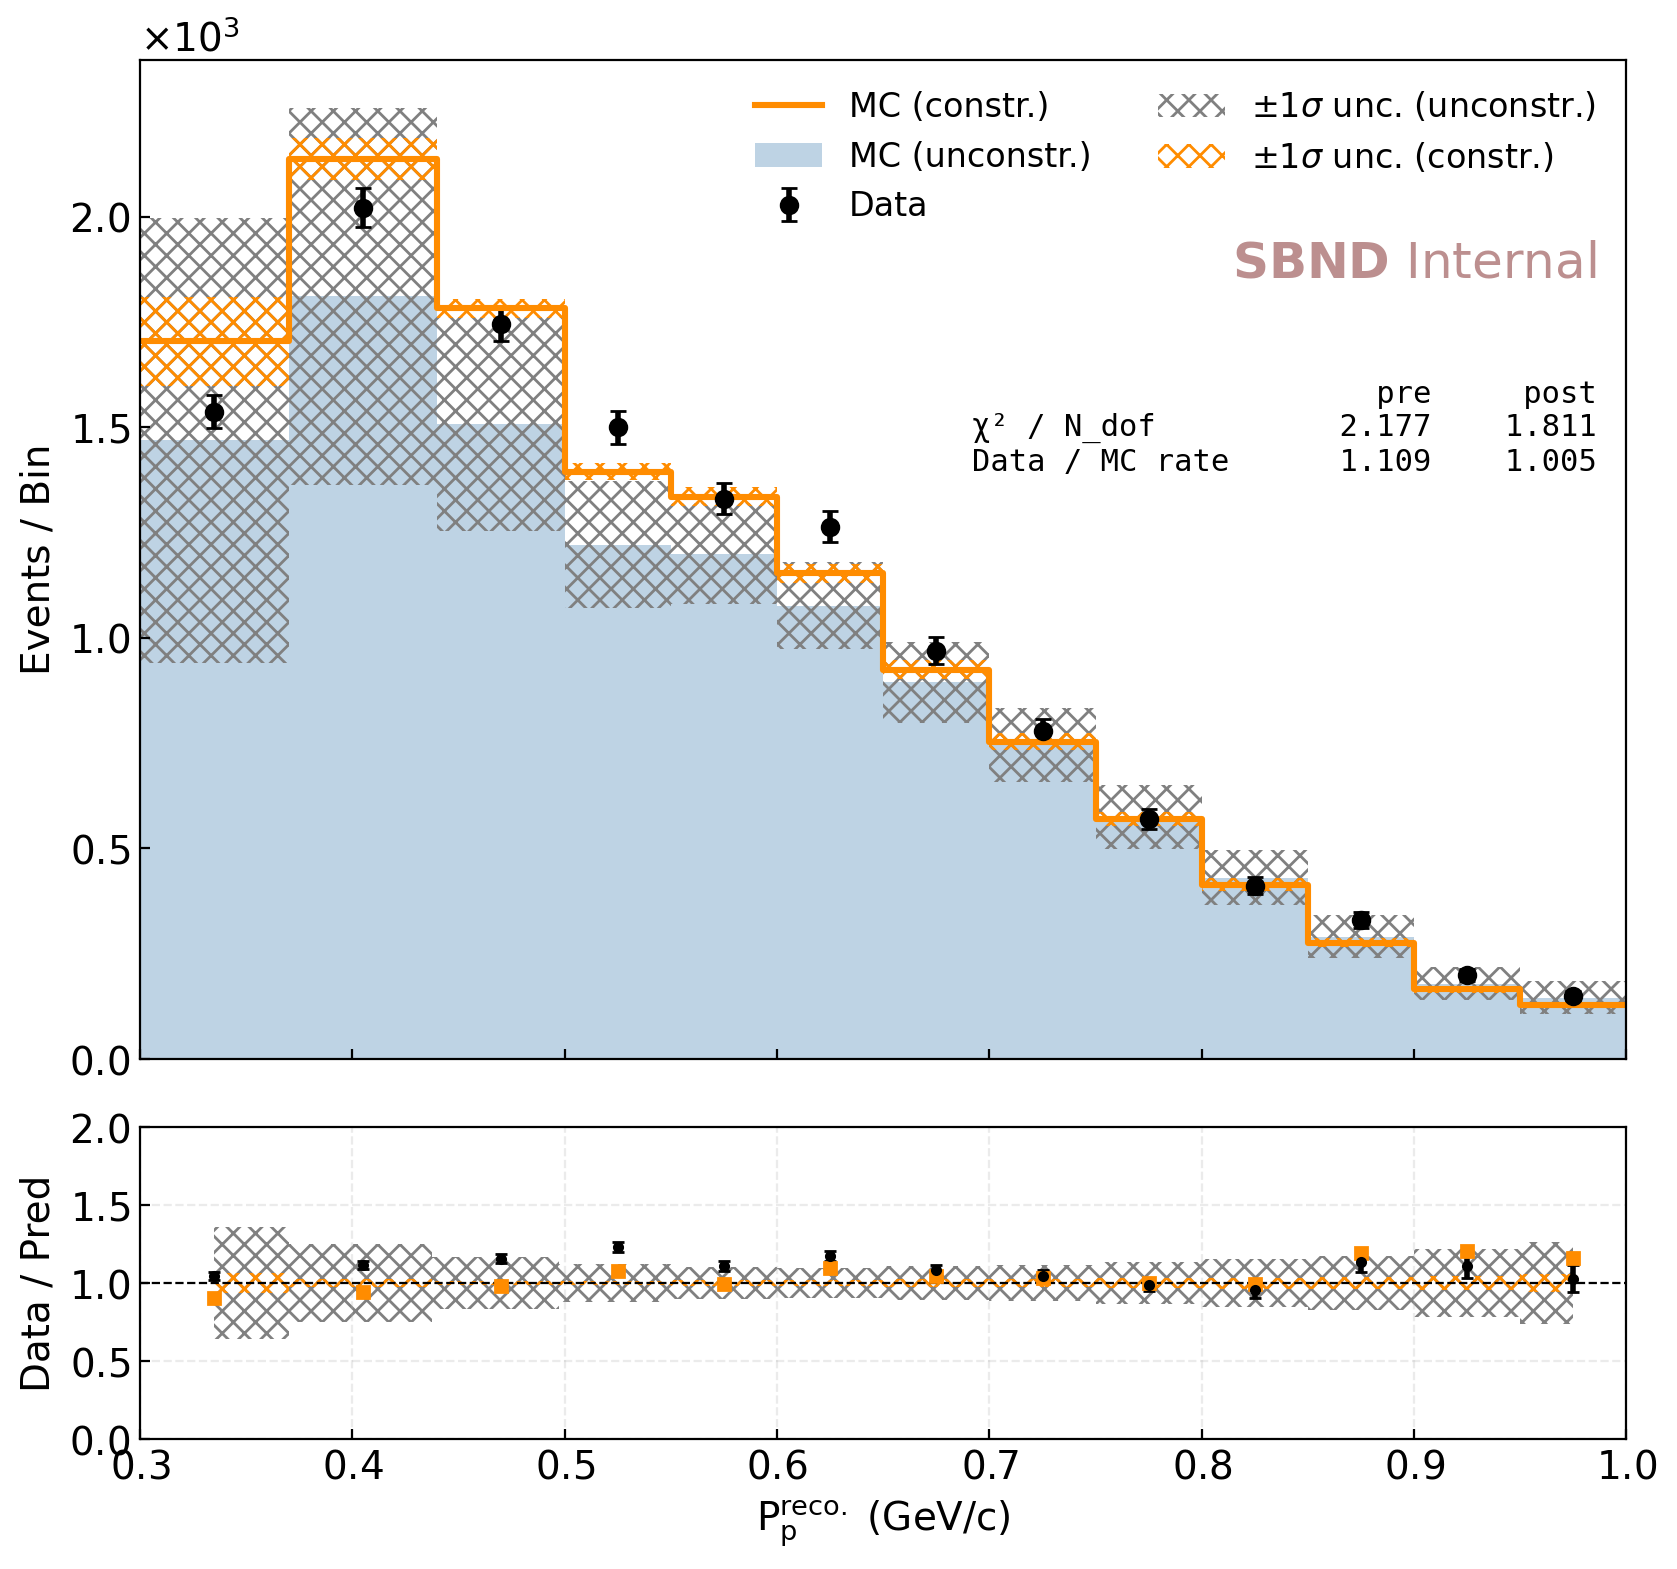

In [133]:
from IPython.display import Image, display

display(Image(filename=str(_figpath)))

In [134]:
_figpath

PosixPath('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana/analysis_village/numucc_1p0pi/notebooks/conditional_constraint_out_notebook/proton_proton-p_conditional.png')